In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize

import psyduck.fit_toolbox
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian, get_fq1, get_fq2, get_quadrupole_stark_shift
from psyduck.tensors import get_R_tensor, voigt_to_tensor
from psyduck.plotting import plot_quadrupole_tensor, spherical_plot_3d, spherical_plot_hammer, spherical_plot_3d_with_projections

In [2]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55 * 1e6 # Nuclear Zeeman splitting (MHz/T)

In [3]:
# round 2

nmr = np.array([
    [5177528, 5196914, 5216357, 5235865, 5255417, 5275028, 5294686],
    [5161529, 5169044, 5176984, 5185315, 5194063, 5203187, 5212704],
    [5193097, 5181625, 5170701, 5160363, 5150582, 5141366, 5132727],
    [5061216, 5033579, 5006232, 4979215, 4952508, 4926134, 4900099],
    [4980129, 4949666, 4919319, 4889099, 4859016, 4829056, 4799213],
    [5000745, 4983736, 4966999, 4950530, 4934354, 4918441, 4902813],
    [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953],
    [5097953, 5116193, 5134430, 5152663, 5170890, 5189114, 5207341],
    [5175598, 5195010, 5214485, 5234018, 5253596, 5273241, 5292925],
    [4979715, 4949215, 4918833, 4888579, 4858463, 4828463, 4798594],
])

thetas = np.array([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5, 180, 270])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
fq_3_measured = np.mean(np.diff(np.diff(np.diff(nmr, axis=1), axis=1), axis=1), axis=1)
f_ner1_measured = 0.5*np.array([
    [1/519697, 1/597295, 1/1064037, 0, 1/1076182,  1/592020,  1/507312],
    [1/469814, 1/537820, 1/964855, 0, 1/959450, 1/539029, 1/467321],
    [1/474313, 1/543768, 1/961922, 0, 1/980673, 1/543890, 1/474970],
    [ 1/599094,  1/679474, 1/1198854, 0, 1/1226728,  1/681987, 1/591860],
    [1/1081992.81, 1/1251703.02, 1/2229890.79, 0, 1/2181519.21, 1/1243226.88, 1/1076215.2],
    [1/2681059, 1/3073828, 1/5336330, 0, 1/5658708, 1/3075752, 1/2609055],
    [1/1133288, 1/1313658, 1/2285002, 0, 1/2434721, 1/1315950, 1/1105150],
    [ 1/682572,  1/778685, 1/1394757, 0, 1/1420564,  1/787685,  1/679665],
    [ 1/530590,  1/607428, 1/1088738, 0,  1/1100366,  1/604772,  1/526999],
    [1/1110162, 1/1274370, 1/2301357, 0, 1/2259099, 1/1279664, 1/1116843]
]) * 1e9
# c = 1/0.5
f_ner2_measured = 0.5/np.array([
    [2059393, 1470940, 1278560, 1282440, 1452975, 2048745],
    [5575075, 4523979, 3669188, 3740429, 4140198, 5637024],
    [3845992, 2585353, 2204919, 2232682, 2553333, 3571300],
    [1523368, 1068814, 930864, 930000, 1068814, 1523368],
    [1093055, 759243, 660288, 657546, 752941, 1060455],
    [976274, 681467, 584440, 589394, 675320, 983801],
    [1084931, 748730, 639388, 647135, 747695, 1081884],
    [1471040, 1051061, 885124, 895757, 1025554, 1486298],
    [2185740, 1563971, 1390545, 1398118, 1606166, 2275523],
    [1156223, 788733, 681452, 677784, 768879 , 1126634]
]) * 1e9
lqse_measured = np.array([167.239, 120.834, -0.684, -105.872, -149.260, -72.705, 43.519, 132.189, 152.620, -141.744])

In [4]:
nmr.shape

(10, 7)

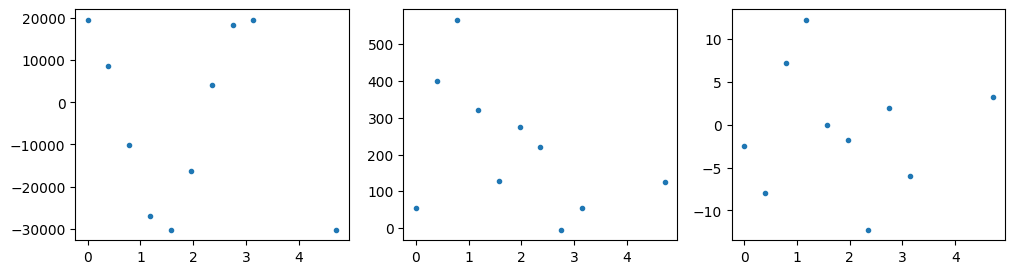

In [5]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
ax[0].plot(thetas, fq_1_measured, '.')
ax[1].plot(thetas, fq_2_measured, '.')
ax[2].plot(thetas, fq_3_measured, '.')

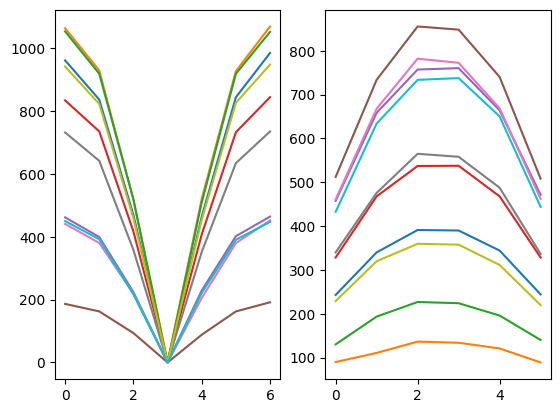

In [6]:
fig, ax = plt.subplots(1,2)
ax[0].plot(f_ner1_measured.T)
ax[1].plot(f_ner2_measured.T)

In [7]:
B0 = np.mean(nmr[0])/GAMMA_NUCLEAR

def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=0.0, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta, phi=phi)
    return H_zeeman + H_q

# R-tensor (Si, (110) orientation): maps AC field [Ex, Ey, Ez] → EFG Voigt vector
_R_tensor = get_R_tensor()   # (6, 3)

def _drive_in_eigenbasis(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0):
    """Drive Hamiltonian (from AC field E_ac) in the energy eigenbasis of H_ion."""
    E_ac       = np.array([E_x, E_y, E_z])
    EFG_tensor = voigt_to_tensor(_R_tensor @ E_ac)
    H_drive    = quadrupole_hamiltonian_from_Vab(I_SPIN, EFG_tensor, Q_N).full()
    H_ion      = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=phi)
    _, evecs   = H_ion.eigenstates()
    U          = np.column_stack([v.full().flatten() for v in evecs])
    return U.conj().T @ H_drive @ U

def ner1(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=phi), 1))

def ner2(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0, scale=1.0, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, scale*E_x, scale*E_y, scale*E_z, phi=phi), 2))

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=0.0, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=phi).eigenstates()[0]
    return np.flip(np.diff(evals)).flatten()

def lqse(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, scale_dc=1.0, **kwargs):
    V_ab = voigt_to_tensor(np.array([Vxx, Vyy, Vzz, Vxy, Vyz, Vxz]))
    E_vec = np.array([E_x, E_y, E_z])
    dfq1_stark, dfq2_stark = get_quadrupole_stark_shift(
        V_ab, E_vec, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, thetas=np.array([theta]), phis=np.array([0])
    )
    return scale_dc * dfq1_stark[0, 0]

In [8]:
fq_3_measured

array([ -2.5 ,  -8.  ,   7.25,  12.25,   0.  ,  -1.75, -12.25,   2.  ,
        -6.  ,   3.25])

In [9]:

def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    fq3_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
        # fq3_arr[t] = np.mean(np.diff(np.diff(np.diff(np.diff(evals)))))
    return np.vstack([
        (fq1_arr - fq_1_measured),
        (fq2_arr - fq_2_measured),
        # (fq3_arr - fq_3_measured),
    ])

params = Parameters()
params.add('Vxx', value=0, min=-5,  max=5)
params.add('Vyy', value=0,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=-1.33,  min=-20, max=20)
params.add('Vyz', value=-1.65,  min=-5,  max=20)
params.add('Vxz', value=0.81,  min=-5,  max=20)
# params.add('scale', value=0, min=0, max=0.1)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.452       -5        5  0.03235     True     None     None
Vxy    -1.364      -20       20    1.682     True     None     None
Vxz    0.6004       -5       20  0.03132     True     None     None
Vyy   -0.7326       -5        5  0.03963     True     None     None
Vyz    -1.287       -5       20    1.723     True     None     None
Vzz     -1.72     -inf      inf  0.03235    False - Vxx - Vyy     None


In [10]:
result

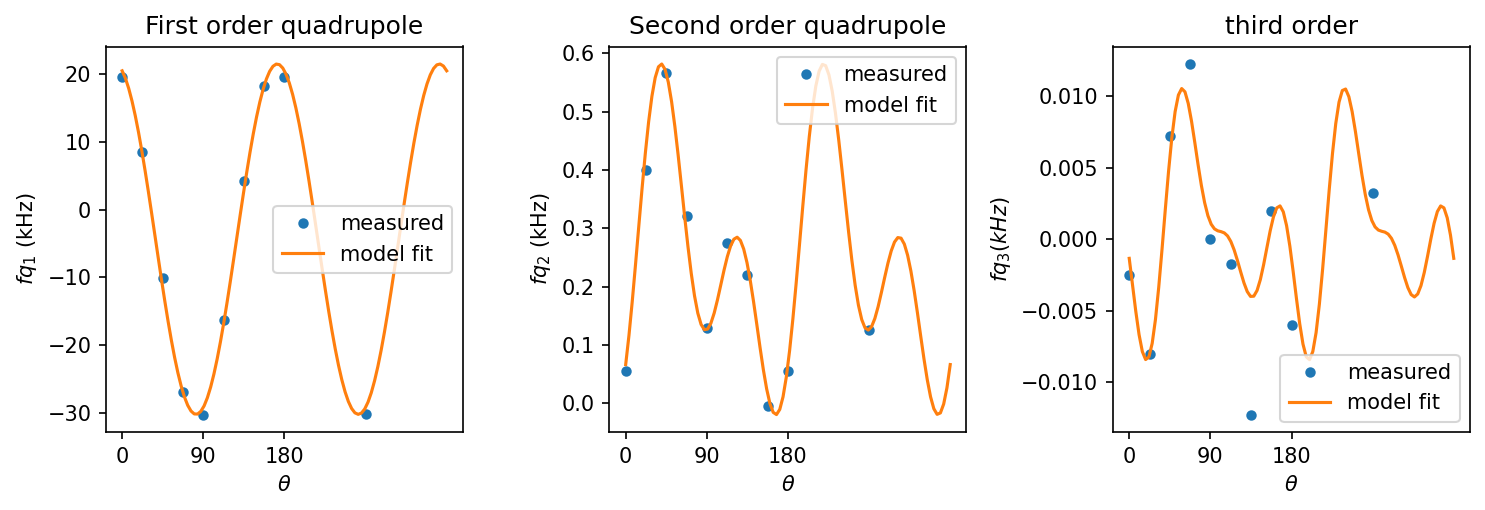

In [11]:
p = result.params.valuesdict()
thetas_fit = np.linspace(0, np.pi*2, 100)
fq1_arr = np.zeros(len(thetas_fit))
fq2_arr = np.zeros(len(thetas_fit))
fq3_arr = np.zeros(len(thetas_fit))
for t, theta in enumerate(thetas_fit):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    fq3_arr[t] = np.mean(np.diff(np.diff(np.diff(np.diff(evals)))))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5), dpi=150)
ax[0].plot(thetas / np.pi * 180, fq_1_measured * 1e-3, '.', markersize=8, label='measured')
ax[0].plot(thetas_fit / np.pi * 180, fq1_arr * 1e-3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq_2_measured * 1e-3, '.', markersize=8, label='measured')
ax[1].plot(thetas_fit / np.pi * 180, fq2_arr * 1e-3, label='model fit')
ax[2].plot(thetas / np.pi * 180, fq_3_measured * 1e-3, '.', markersize=8, label='measured')
ax[2].plot(thetas_fit / np.pi * 180, fq3_arr * 1e-3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole', 'third order'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)', '$fq_3 (kHz)$']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

In [55]:
p_tensor = result.params.valuesdict()

In [56]:
p = result.params.valuesdict()
ner1_arr = np.zeros((len(thetas), 7))
ner2_arr = np.zeros((len(thetas), 6))
for t, theta in enumerate(thetas):
    ner1_arr[t] = ner1(theta, **p, E_x=100000, E_y=100000, E_z=100000)
    ner2_arr[t] = ner2(theta, **p, E_x=40000, E_y=40000, E_z=100000)

In [57]:
ner1_arr

array([[536.63595344, 471.10731199, 266.86218694,   6.32368655,
        255.64491573, 463.47382141, 533.86218858],
       [478.80084379, 421.29441744, 240.04843397,   9.98108587,
        225.26362821, 410.81395717, 474.29183586],
       [531.12698123, 468.53333601, 267.26523251,  11.84341771,
        255.27329491, 465.8527777 , 539.31720729],
       [475.05402912, 417.11430974, 236.04825368,   8.71441801,
        229.13411083, 414.91478625, 478.46121652],
       [538.48877185, 470.6296325 , 264.44444434,   3.42714639,
        257.90534366, 463.7337147 , 531.88779008],
       [790.92618046, 694.99929236, 393.43733971,   7.22247049,
        382.52297958, 693.20234202, 799.69499974],
       [924.1964406 , 810.1822099 , 456.60273567,   5.46432545,
        448.16928471, 808.29725568, 929.95624656],
       [796.26741355, 696.32534699, 391.01846562,   3.90005512,
        385.08089457, 691.93937079, 794.09319433],
       [536.63595344, 471.10731199, 266.86218694,   6.32368655,
        255.6449

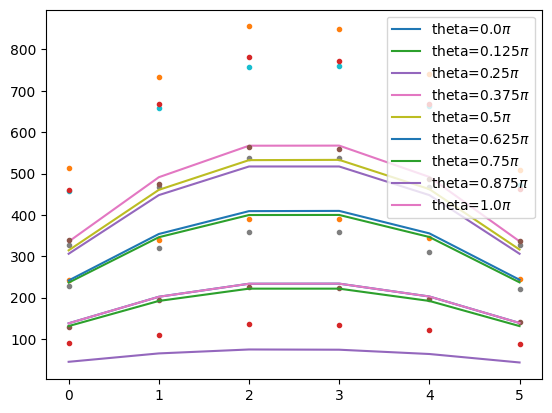

In [58]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner2_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner2_measured[t], '.')
plt.legend()

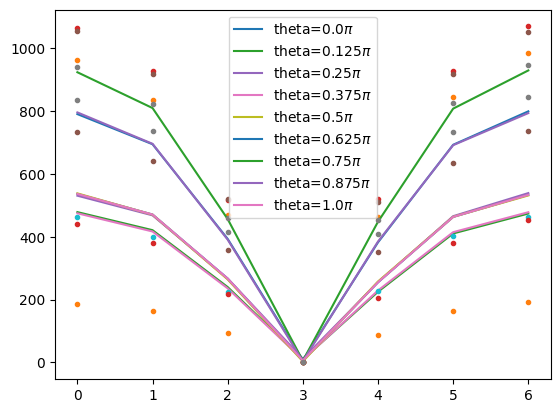

In [59]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner1_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner1_measured[t], '.')
plt.legend()

In [60]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p_tensor, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p_tensor, **p)
        ner2_arr[t]  = ner2(theta, **p_tensor, **p)
    return np.hstack([
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('E_x', value=4,   min=-1e7, max=1e7)
params.add('E_y', value=-5,  min=-1e7, max=1e7)
params.add('E_z', value=10,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)


result_full = minimize(residual_full, params, method='leastsq')
result_full


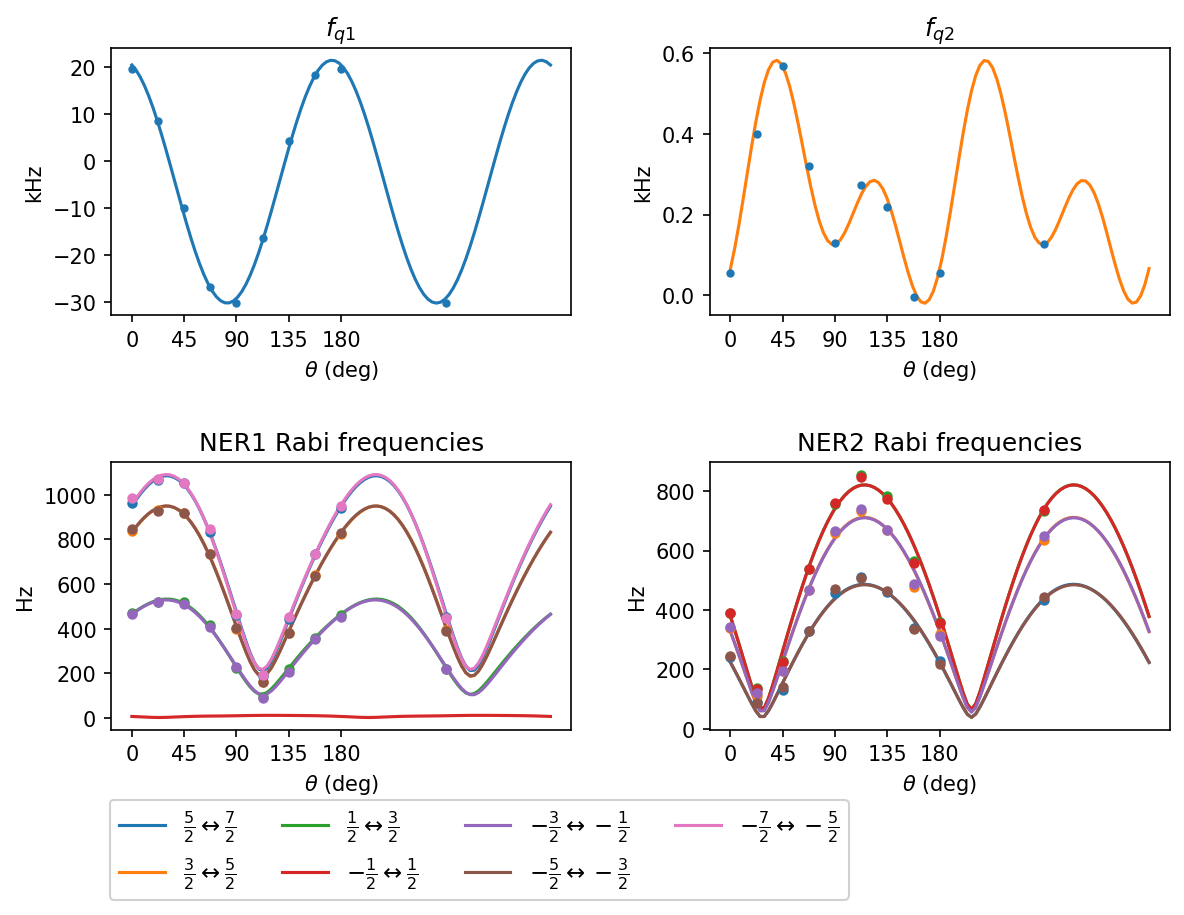

In [61]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi*2, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_tensor, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_tensor, **p_full)
    ner2_fit[t]  = ner2(th, **p_tensor, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=11, ncol=4, loc='upper center',
               bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)
plt.savefig(r'quadrupole_data.png', dpi=300)

## fit simultaneously

In [62]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    lqse_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p)
        ner2_arr[t]  = ner2(theta, **p)
        lqse_arr[t]  = lqse(theta, **p)
    return np.hstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
        (lqse_arr - lqse_measured)/ np.max(np.abs(lqse_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('Vxx', value=5, min=-5,  max=5)
params.add('Vyy', value=3,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)
params.add('E_x', value=-50266,   min=-1e7, max=1e7)
params.add('E_y', value=129098,  min=-1e7, max=1e7)
params.add('E_z', value=268649,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)
params.add('scale_dc', value=-300000)


result_full = minimize(residual_full, params, method='leastsq')
result_full

In [66]:
p_full = result.params.valuesdict()
V_ab = make_V_ab(p_full['Vxx'], p_full['Vyy'], p_full['Vzz'],
                 p_full['Vxy'], p_full['Vyz'], p_full['Vxz'])
print('V_ab (V/m²):\n', V_ab)
np.save('V_ab_fit.npy', V_ab)

V_ab (V/m²):
 [[ 2.45226360e+19 -1.36411819e+19  6.00442405e+18]
 [-1.36411819e+19 -7.32643770e+18 -1.28685299e+19]
 [ 6.00442405e+18 -1.28685299e+19 -1.71961983e+19]]


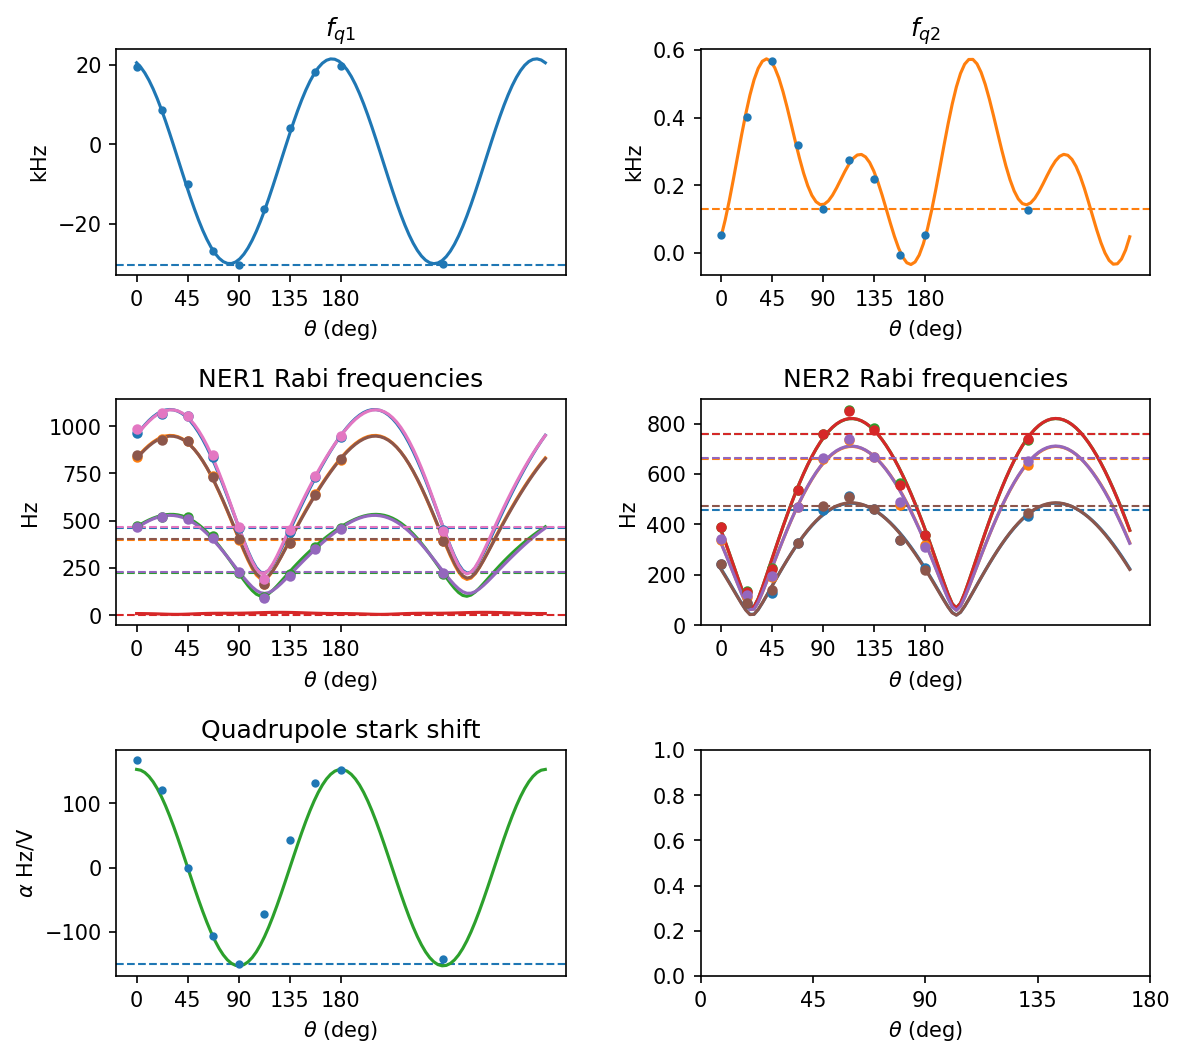

In [53]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi*2, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
lqse_fit = np.zeros(len(thetas_fit))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_full)
    ner2_fit[t]  = ner2(th, **p_full)
    lqse_fit[t]  = lqse(th, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(3, 2, figsize=(8, 8), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].axhline(fq_1_measured[4]*1e-3, ls='--', lw=1)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].axhline(fq_2_measured[4]*1e-3, ls='--', lw=1, color='C1')
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
    axes[2].axhline(f_ner1_measured[4, i], color=c, ls='--', lw=1)
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
# axes[2].legend(fontsize=11, ncol=4, loc='upper center',
#                bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
    axes[3].axhline(f_ner2_measured[4, i], color=c, ls='--', lw=1)
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')

# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

axes[4].plot(theta_deg, lqse_measured, '.', zorder=5)
axes[4].axhline(lqse_measured[4], ls='--', lw=1)
axes[4].plot(theta_fit_deg, lqse_fit, color='C2')
axes[4].set_ylabel(r'$\alpha$ Hz/V')
axes[4].set_title('Quadrupole stark shift')
for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)
plt.savefig(r'quadrupole_data.png', dpi=300)

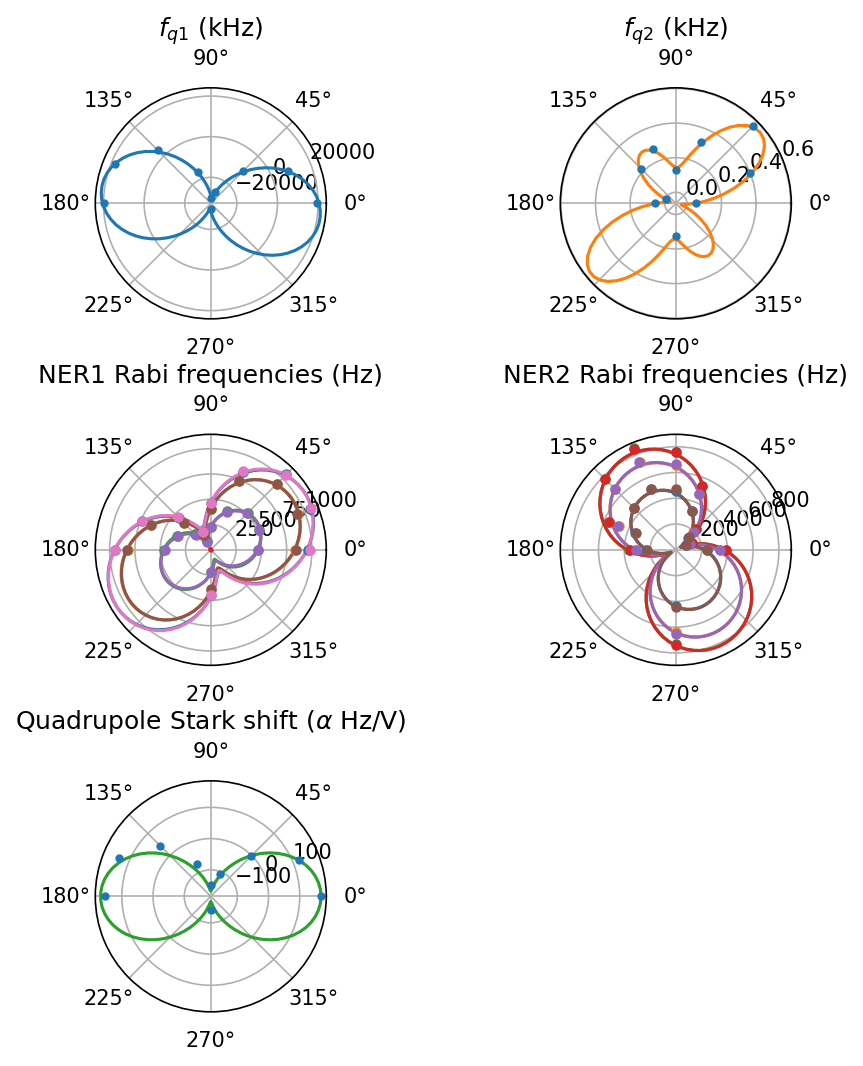

In [54]:
fig, ax = plt.subplots(3, 2, figsize=(8, 8), dpi=150,
                        subplot_kw=dict(projection='polar'),
                       gridspec_kw=dict(hspace=0.5, wspace=0))
axes = ax.flatten()

axes[0].plot(thetas, fq_1_measured, '.', zorder=5)
axes[0].plot(thetas_fit, fq1_fit, color='C0')
axes[0].set_title('$f_{q1}$ (kHz)')

axes[1].plot(thetas, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(thetas_fit, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$ (kHz)')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(thetas[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8, color=c, zorder=5)
    axes[2].plot(thetas_fit, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies (Hz)')

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(thetas, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(thetas_fit, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies (Hz)')

axes[4].plot(thetas, lqse_measured, '.', zorder=5)
axes[4].plot(thetas_fit, 1.1*lqse_fit, color='C2')
axes[4].set_title(r'Quadrupole Stark shift ($\alpha$ Hz/V)')

axes[5].set_visible(False)

fig.subplots_adjust(wspace=0.4, hspace=0.6)
plt.savefig(r'quadrupole_data_polar.png', dpi=300)

## correct misalignment

Due to symmetry reasons, the Quadrupole stark shift should be symmetric around 90 degrees granted that the chip is aligned with the magnet axes. There seems to be a misalignment in the zx plane. We can first fit a sine to the LQSE data and extract the misalignment angle in zx.

phase offset =  7.064712881890029 degrees


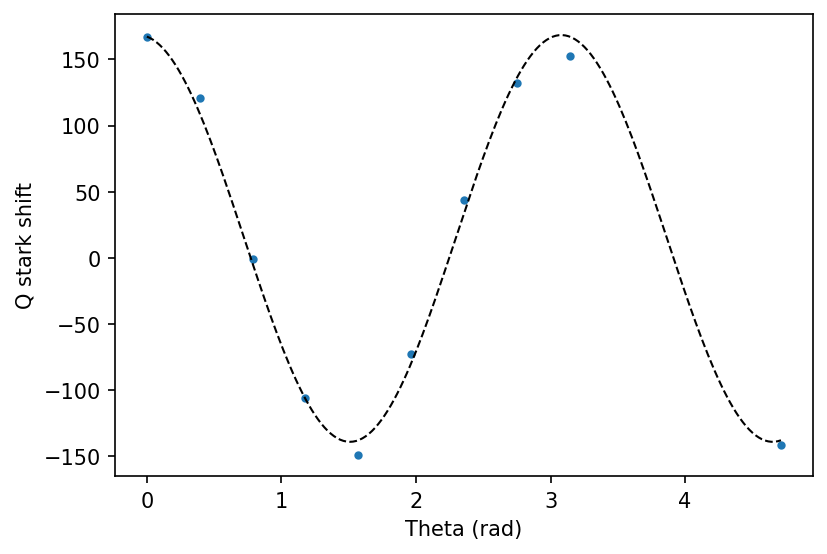

In [43]:
from psyduck.fit_toolbox import SineFit
lqse_result = SineFit(lqse_measured, xvals=thetas, fixed_parameters={'frequency': 1/np.pi})
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.plot(thetas, lqse_measured, '.', label='measured')
lqse_result.add_to_plot(ax, lw=1)
ax.set_xlabel('Theta (rad)')
ax.set_ylabel('Q stark shift')
phase_offset = (lqse_result.fit_result.params['phase'] - np.pi/2)
print('phase offset = ', phase_offset/np.pi*180, 'degrees')

## export tensor

## Full fit with phase offset

Re-run the simultaneous fit including `theta_offset` as a free parameter, initialized from the sine fit above. The offset shifts all measured angles: `theta_eff = theta + theta_offset`.

In [49]:
_ner1_mask = f_ner1_measured != 0

def residual_full_misaligned(params):
    p = params.valuesdict()
    theta_offset = p.pop('theta_offset')
    thetas_eff = thetas + theta_offset

    fq1_arr  = np.zeros(len(thetas))
    fq2_arr  = np.zeros(len(thetas))
    ner1_arr = np.zeros((len(thetas), 7))
    ner2_arr = np.zeros((len(thetas), 6))
    lqse_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas_eff):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]  = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]  = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t] = ner1(theta, **p)
        ner2_arr[t] = ner2(theta, **p)
        lqse_arr[t] = lqse(theta, **p)
    return np.hstack([
        (fq1_arr  - fq_1_measured)                        / np.max(np.abs(fq_1_measured)),
        (fq2_arr  - fq_2_measured)                        / np.max(np.abs(fq_2_measured)),
        (ner1_arr - f_ner1_measured)[_ner1_mask]          / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()            / np.max(np.abs(f_ner2_measured)),
        (lqse_arr - lqse_measured)                        / np.max(np.abs(lqse_measured)),
    ])

p0 = result_full.params.valuesdict()
params_misaligned = Parameters()
params_misaligned.add('Vxx',          value=p0['Vxx'],      min=-5,   max=5)
params_misaligned.add('Vyy',          value=p0['Vyy'],      min=-5,   max=5)
params_misaligned.add('Vzz',          expr='- Vxx - Vyy')
params_misaligned.add('Vxy',          value=p0['Vxy'],      min=-20,  max=20)
params_misaligned.add('Vyz',          value=p0['Vyz'],      min=-5,   max=20)
params_misaligned.add('Vxz',          value=p0['Vxz'],      min=-5,   max=20)
params_misaligned.add('E_x',          value=p0['E_x'],      min=-1e7, max=1e7)
params_misaligned.add('E_y',          value=p0['E_y'],      min=-1e7, max=1e7)
params_misaligned.add('E_z',          value=p0['E_z'],      min=-1e7, max=1e7)
params_misaligned.add('scale',        value=p0['scale'],    min=0.00001, max=10)
params_misaligned.add('scale_dc',     value=p0['scale_dc'])
params_misaligned.add('theta_offset', value=phase_offset,   min=-np.pi/4, max=np.pi/4)

result_misaligned = minimize(residual_full_misaligned, params_misaligned, method='leastsq')
result_misaligned

In [1]:
fq_2_measured

NameError: name 'fq_2_measured' is not defined

Fitted theta_offset = 3.330 deg


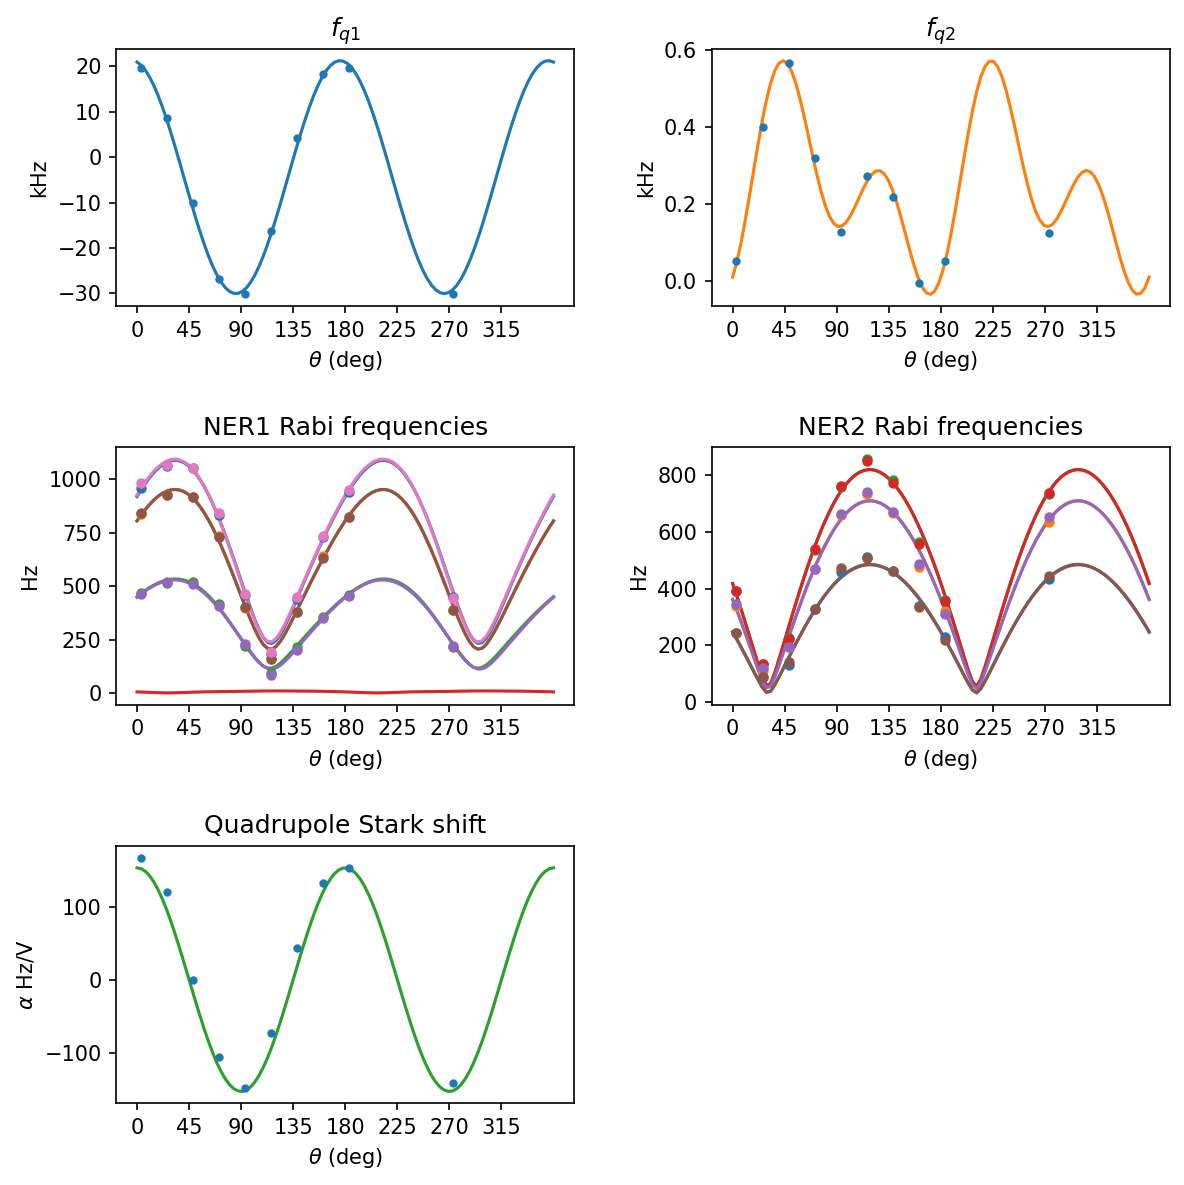

In [51]:
p_mis = result_misaligned.params.valuesdict()
theta_offset_fit = p_mis.pop('theta_offset')
print(f'Fitted theta_offset = {theta_offset_fit/np.pi*180:.3f} deg')

thetas_fit = np.linspace(0, np.pi * 2, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
lqse_fit = np.zeros(len(thetas_fit))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_mis).eigenstates()[0]
    fq1_fit[t]  = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]  = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t] = ner1(th, **p_mis)
    ner2_fit[t] = ner2(th, **p_mis)
    lqse_fit[t] = lqse(th, **p_mis)

# Shift the measured thetas by the fitted offset for plotting alignment
thetas_shifted     = thetas + theta_offset_fit
theta_shifted_deg  = thetas_shifted / np.pi * 180
theta_fit_deg      = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(3, 2, figsize=(8, 8), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_shifted_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_shifted_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_shifted_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8, color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_shifted_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')

axes[4].plot(theta_shifted_deg, lqse_measured, '.', zorder=5)
axes[4].plot(theta_fit_deg, lqse_fit, color='C2')
axes[4].set_ylabel(r'$\alpha$ Hz/V')
axes[4].set_title('Quadrupole Stark shift')

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180, 225, 270, 315])

axes[5].set_visible(False)
fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55)
plt.savefig(r'quadrupole_data_misaligned.png', dpi=300)

## elliptical angles

ESR/NMR ratio range: 5064.41 – 5065.87  (constant → B0 variation, not g anisotropy)


C:\Users\z5380600\AppData\Local\Temp\ipykernel_25676\1293607685.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend(fontsize=8); a.set_xticks([0, 45, 90, 135, 180])


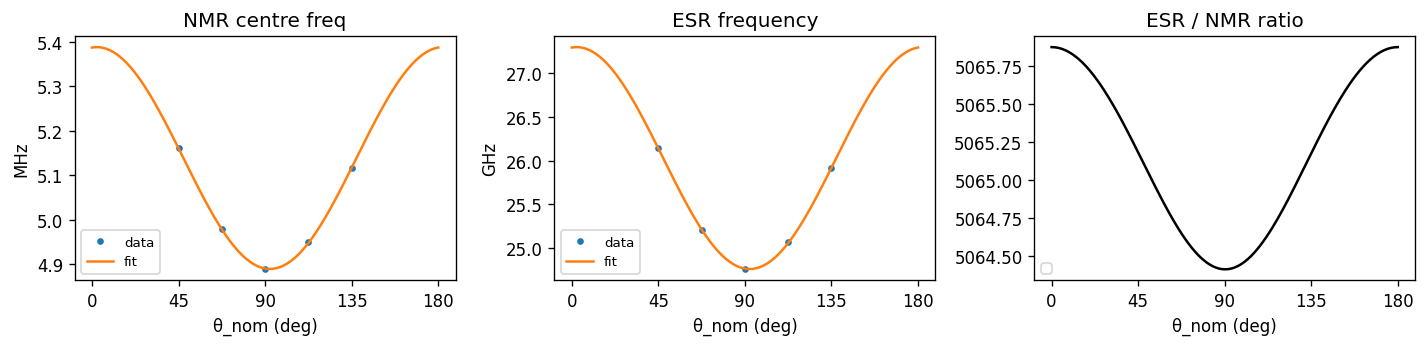

In [68]:
# ESR frequencies at each measured theta (from extracting_quadrupole_tensor_few_angles.ipynb)
f_ESR = 27184250000.0
esr = np.array([
    int(f_ESR - 691.85e6 + 26.5e6),          # θ =   0°
    int(f_ESR - 916.76e6),                    # θ =  22.5°
    int(f_ESR - 1042.12e6),                   # θ =  45°
    int(f_ESR - 1972.36e6),                   # θ =  67.5°
    int(f_ESR - 2424.72e6),                   # θ =  90°
    int(f_ESR - 2116.78e6 + 4.6e6),          # θ = 112.5°
    int(f_ESR - 1272.44e6),                   # θ = 135°
    int(f_ESR - 1013.09e6 - 74e6),           # θ = 157.5°
    int(f_ESR - 691.85e6 + 26.5e6 - 8e6),   # θ = 180°
    int(f_ESR - 2424.72e6),                   # θ = 270°
])

# Fit range: exclude θ=0°, 22.5° (different-B0 run) and θ=157.5°, 180°, 270° (outliers)
# → keeps θ = 45°, 67.5°, 90°, 112.5°, 135° (same exclusion as few_angles notebook)
_valid = slice(2, -3)
_A = np.column_stack([np.ones(5),
                      np.cos(2 * thetas[_valid]),
                      np.sin(2 * thetas[_valid])])

_coeffs_nmr, *_ = np.linalg.lstsq(_A, nmr[_valid, 3], rcond=None)
_coeffs_esr, *_ = np.linalg.lstsq(_A, esr[_valid],    rcond=None)

def center_sinusoid(theta):
    """Sinusoidal fit to NMR centre frequency (Hz) vs nominal angle."""
    return _coeffs_nmr[0] + _coeffs_nmr[1]*np.cos(2*theta) + _coeffs_nmr[2]*np.sin(2*theta)

def esr_sinusoid(theta):
    """Sinusoidal fit to ESR frequency (Hz) vs nominal angle."""
    return _coeffs_esr[0] + _coeffs_esr[1]*np.cos(2*theta) + _coeffs_esr[2]*np.sin(2*theta)

_theta_curve = np.linspace(0, np.pi, 200)
_ratio = esr_sinusoid(_theta_curve) / center_sinusoid(_theta_curve)
print(f'ESR/NMR ratio range: {_ratio.min():.2f} – {_ratio.max():.2f}  '
      f'(constant → B0 variation, not g anisotropy)')

fig, axes = plt.subplots(1, 3, figsize=(12, 3), dpi=120)
axes[0].plot(thetas[_valid]/np.pi*180, nmr[_valid, 3]*1e-6, '.', label='data')
axes[0].plot(_theta_curve/np.pi*180, center_sinusoid(_theta_curve)*1e-6, label='fit')
axes[0].set(title='NMR centre freq', ylabel='MHz', xlabel='θ_nom (deg)')
axes[1].plot(thetas[_valid]/np.pi*180, esr[_valid]*1e-9, '.', label='data')
axes[1].plot(_theta_curve/np.pi*180, esr_sinusoid(_theta_curve)*1e-9, label='fit')
axes[1].set(title='ESR frequency', ylabel='GHz', xlabel='θ_nom (deg)')
axes[2].plot(_theta_curve/np.pi*180, _ratio, 'k')
axes[2].set(title='ESR / NMR ratio', xlabel='θ_nom (deg)')
for a in axes:
    a.legend(fontsize=8); a.set_xticks([0, 45, 90, 135, 180])
fig.tight_layout()

B0 along z (θ=0):    970.6337 mT
B0 along x (θ=90°):  881.1581 mT
Axis ratio B0x/B0z = 0.907817  (deviation from circle: 9.218 %)

  θ_nom (°)  →  θ_adj (°)    B0_actual (mT)
      0.0     →     0.000       970.6337
     22.5     →    20.608       960.2900
     45.0     →    42.234       929.7986
     67.5     →    65.474       897.0211
     90.0     →    90.000       881.1581
    112.5     →   114.526       891.5018
    135.0     →   137.766       921.9932
    157.5     →   159.392       954.7707
    180.0     →   180.000       970.6337
    270.0     →   270.000       881.1581


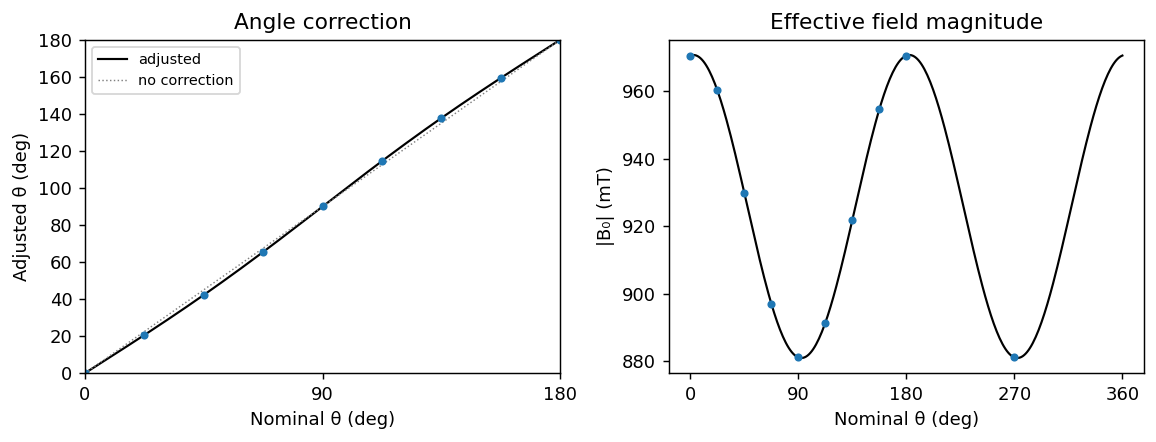

In [74]:
# Ellipse parameters from NMR centre sinusoid
#
# The rotation sweeps B in the xz-plane:
#   B(θ_nom) = B0z·cos(θ_nom)·ẑ + B0x·sin(θ_nom)·x̂
#
# B0z and B0x are read directly from the sinusoid at θ=0 and θ=π/2:
B0z = center_sinusoid(0)          / GAMMA_NUCLEAR   # T
B0x = center_sinusoid(np.pi / 2)  / GAMMA_NUCLEAR   # T
r   = B0x / B0z                                     # axis ratio (< 1 → weaker along x)

print(f'B0 along z (θ=0):    {B0z*1e3:.4f} mT')
print(f'B0 along x (θ=90°):  {B0x*1e3:.4f} mT')
print(f'Axis ratio B0x/B0z = {r:.6f}  (deviation from circle: {(1-r)*100:.3f} %)')

# Adjusted angle: arctan2 handles all four quadrants correctly
def theta_adjusted(theta_nom):
    """Convert nominal sweep angle to true B-field polar angle (rad)."""
    adj = np.arctan2(r * np.sin(theta_nom), np.cos(theta_nom))
    return np.where(np.asarray(adj) < 0, adj + 2*np.pi, adj)

# Actual |B| at each nominal angle (use NMR centre-freq sinusoid as the B0 proxy)
def B0_actual(theta_nom):
    """True field magnitude at nominal angle θ_nom (T)."""
    return center_sinusoid(theta_nom) / GAMMA_NUCLEAR

# --- Corrected angles for the measured data points ---
thetas_adj   = theta_adjusted(thetas)
B0_at_thetas = B0_actual(thetas)

print('\n  θ_nom (°)  →  θ_adj (°)    B0_actual (mT)')
for th_nom, th_adj, b0 in zip(thetas/np.pi*180, thetas_adj/np.pi*180, B0_at_thetas*1e3):
    print(f'   {th_nom:6.1f}     →   {th_adj:7.3f}       {b0:.4f}')

# --- Dense grid for fit curves ---
_thetas_fit = np.linspace(0, 2*np.pi, 300)
thetas_fit_adj   = theta_adjusted(_thetas_fit)
B0_at_thetas_fit = B0_actual(_thetas_fit)

# --- Visualise the correction ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), dpi=130)

axes[0].plot(_thetas_fit/np.pi*180, thetas_fit_adj/np.pi*180, 'k', lw=1.2, label='adjusted')
axes[0].plot([0, 360], [0, 360], 'grey', lw=0.8, ls=':', label='no correction')
axes[0].plot(thetas/np.pi*180, thetas_adj/np.pi*180, 'C0.', markersize=7)
axes[0].set(xlabel='Nominal θ (deg)', ylabel='Adjusted θ (deg)', title='Angle correction')
axes[0].set_xticks([0, 90, 180, 270, 360]); axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 180)
axes[0].set_ylim(0, 180)

axes[1].plot(_thetas_fit/np.pi*180, B0_at_thetas_fit*1e3, 'k', lw=1.2)
axes[1].plot(thetas/np.pi*180, B0_at_thetas*1e3, 'C0.', markersize=7)
axes[1].set(xlabel='Nominal θ (deg)', ylabel='|B₀| (mT)', title='Effective field magnitude')
axes[1].set_xticks([0, 90, 180, 270, 360])

fig.tight_layout()

## fit with adjusted angles

In [71]:
_ner1_mask = f_ner1_measured != 0

def residual_full_misaligned(params):
    p = params.valuesdict()
    theta_offset = p.pop('theta_offset')
    thetas_eff = thetas_adj + theta_offset

    fq1_arr  = np.zeros(len(thetas_eff))
    fq2_arr  = np.zeros(len(thetas_eff))
    ner1_arr = np.zeros((len(thetas_eff), 7))
    ner2_arr = np.zeros((len(thetas_eff), 6))
    lqse_arr = np.zeros(len(thetas_eff))
    for t, theta in enumerate(thetas_eff):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]  = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]  = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t] = ner1(theta, **p)
        ner2_arr[t] = ner2(theta, **p)
        lqse_arr[t] = lqse(theta, **p)
    return np.hstack([
        (fq1_arr  - fq_1_measured)                        / np.max(np.abs(fq_1_measured)),
        (fq2_arr  - fq_2_measured)                        / np.max(np.abs(fq_2_measured)),
        (ner1_arr - f_ner1_measured)[_ner1_mask]          / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()            / np.max(np.abs(f_ner2_measured)),
        (lqse_arr - lqse_measured)                        / np.max(np.abs(lqse_measured)),
    ])

p0 = result_full.params.valuesdict()
params_misaligned = Parameters()
params_misaligned.add('Vxx',          value=p0['Vxx'],      min=-5,   max=5)
params_misaligned.add('Vyy',          value=p0['Vyy'],      min=-5,   max=5)
params_misaligned.add('Vzz',          expr='- Vxx - Vyy')
params_misaligned.add('Vxy',          value=p0['Vxy'],      min=-20,  max=20)
params_misaligned.add('Vyz',          value=p0['Vyz'],      min=-5,   max=20)
params_misaligned.add('Vxz',          value=p0['Vxz'],      min=-5,   max=20)
params_misaligned.add('E_x',          value=p0['E_x'],      min=-1e7, max=1e7)
params_misaligned.add('E_y',          value=p0['E_y'],      min=-1e7, max=1e7)
params_misaligned.add('E_z',          value=p0['E_z'],      min=-1e7, max=1e7)
params_misaligned.add('scale',        value=p0['scale'],    min=0.00001, max=10)
params_misaligned.add('scale_dc',     value=p0['scale_dc'])
params_misaligned.add('theta_offset', value=phase_offset,   min=-np.pi/4, max=np.pi/4)

result_misaligned = minimize(residual_full_misaligned, params_misaligned, method='leastsq')
result_misaligned

Fitted theta_offset = 3.272 deg


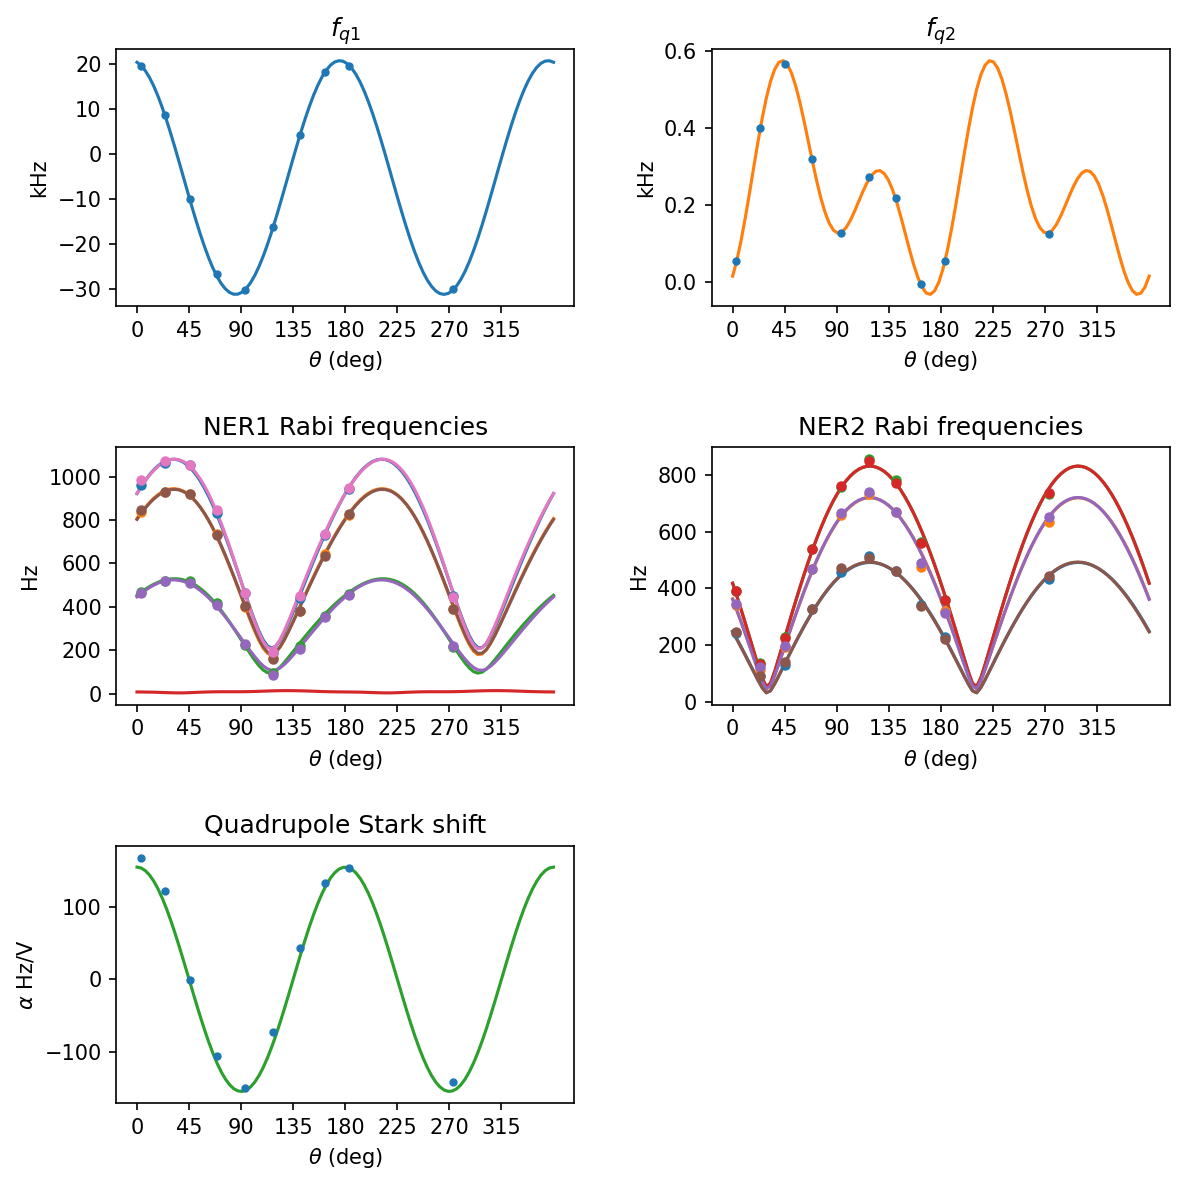

In [73]:
p_mis = result_misaligned.params.valuesdict()
theta_offset_fit = p_mis.pop('theta_offset')
print(f'Fitted theta_offset = {theta_offset_fit/np.pi*180:.3f} deg')

thetas_fit = np.linspace(0, np.pi * 2, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
lqse_fit = np.zeros(len(thetas_fit))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_mis).eigenstates()[0]
    fq1_fit[t]  = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]  = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t] = ner1(th, **p_mis)
    ner2_fit[t] = ner2(th, **p_mis)
    lqse_fit[t] = lqse(th, **p_mis)

# Shift the measured thetas by the fitted offset for plotting alignment
thetas_shifted     = thetas_adj + theta_offset_fit
theta_shifted_deg  = thetas_shifted / np.pi * 180
theta_fit_deg      = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(3, 2, figsize=(8, 8), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_shifted_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_shifted_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_shifted_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8, color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_shifted_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')

axes[4].plot(theta_shifted_deg, lqse_measured, '.', zorder=5)
axes[4].plot(theta_fit_deg, lqse_fit, color='C2')
axes[4].set_ylabel(r'$\alpha$ Hz/V')
axes[4].set_title('Quadrupole Stark shift')

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180, 225, 270, 315])

axes[5].set_visible(False)
fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55)
plt.savefig(r'quadrupole_data_misaligned.png', dpi=300)